Predictive model in ML (Running duration)


In [1]:
#  Data Cleaning 

import pandas as pd
import numpy as np

# 1. Load dataset
file_path = "cardioActivities.csv"
df = pd.read_csv(file_path)

print("Original shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# 2. Remove duplicate rows
duplicates = df.duplicated().sum()
print("\nDuplicate rows:", duplicates)

df = df.drop_duplicates().copy()

# 3. Keep only running activities
print("\nActivity types before filtering:")
print(df["Type"].value_counts(dropna=False))

df = df[df["Type"] == "Running"].copy()
print("\nShape after filtering only Running:", df.shape)

# 4. Convert Date column
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Create date-based features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.day_name()

# 5. Convert Duration to numeric minutes
def duration_to_minutes(x):
    if pd.isna(x):
        return np.nan
    
    parts = str(x).split(":")
    
    try:
        if len(parts) == 3:
            h, m, s = map(int, parts)
            return h * 60 + m + s / 60
        elif len(parts) == 2:
            m, s = map(int, parts)
            return m + s / 60
        else:
            return np.nan
    except:
        return np.nan

df["Duration_min"] = df["Duration"].apply(duration_to_minutes)

# 6. Convert Average Pace to numeric minutes/km
def pace_to_min(x):
    if pd.isna(x):
        return np.nan
    
    parts = str(x).split(":")
    
    try:
        if len(parts) == 2:
            m, s = map(int, parts)
            return m + s / 60
        else:
            return np.nan
    except:
        return np.nan

df["Average_Pace_min_per_km"] = df["Average Pace"].apply(pace_to_min)

# 7. Add missing-value flag before imputation
df["HR_missing_flag"] = df["Average Heart Rate (bpm)"].isna().astype(int)

# Fill missing HR with median
hr_median = df["Average Heart Rate (bpm)"].median()
df["Average Heart Rate (bpm)"] = df["Average Heart Rate (bpm)"].fillna(hr_median)

# 8. Drop columns not needed
drop_cols = [
    "Activity Id",
    "Route Name",
    "Friend's Tagged",
    "Notes",
    "GPX File"
]

df = df.drop(columns=drop_cols, errors="ignore")

# Keep original Duration and Average Pace for reference if wanted
# But for ML we will use separate columns later

# 9. Remove rows with essential missing values
essential_cols = [
    "Date",
    "Distance (km)",
    "Climb (m)",
    "Calories Burned",
    "Duration_min"
]

df = df.dropna(subset=essential_cols).copy()

# 10. Remove invalid values
df = df[
    (df["Distance (km)"] > 0) &
    (df["Duration_min"] > 0) &
    (df["Climb (m)"] >= 0) &
    (df["Calories Burned"] > 0)
].copy()

# 11. Mild outlier trimming using quantiles
# This is more professional than hard-coding extreme limits
outlier_cols = ["Distance (km)", "Duration_min"]

for col in outlier_cols:
    before = df.shape[0]
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df = df[(df[col] >= lower) & (df[col] <= upper)].copy()
    after = df.shape[0]
    print(f"{col}: removed {before - after} rows using 1st-99th percentile trimming")
df = df.reset_index(drop=True)

# 12. Final inspection
print("\nFinal cleaned shape:", df.shape)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 cleaned rows:")
print(df.head())

# 13. Save dashboard-ready cleaned dataset
df.to_csv("cleaned_cardioActivities_dashboard.csv", index=False)
print("\nSaved: cleaned_cardioActivities_dashboard.csv")

# 14. Create ML-ready dataset
# Remove leakage-prone columns for duration prediction
ml_df = df[[
    "Distance (km)",
    "Climb (m)",
    "Average Heart Rate (bpm)",
    "Calories Burned",
    "Year",
    "Month",
    "Day",
    "HR_missing_flag",
    "Duration_min"
]].copy()

# Optional: keep Weekday if you want to encode later
# ml_df["Weekday"] = df["Weekday"]

print("\nML dataset shape:", ml_df.shape)
print("\nML dataset preview:")
print(ml_df.head())

ml_df.to_csv("cleaned_cardioActivities_ml.csv", index=False)
print("\nSaved: cleaned_cardioActivities_ml.csv")

Original shape: (508, 14)

Columns:
['Date', 'Activity Id', 'Type', 'Route Name', 'Distance (km)', 'Duration', 'Average Pace', 'Average Speed (km/h)', 'Calories Burned', 'Climb (m)', 'Average Heart Rate (bpm)', "Friend's Tagged", 'Notes', 'GPX File']

Duplicate rows: 0

Activity types before filtering:
Type
Running    459
Cycling     29
Walking     18
Other        2
Name: count, dtype: int64

Shape after filtering only Running: (459, 14)
Distance (km): removed 10 rows using 1st-99th percentile trimming
Duration_min: removed 10 rows using 1st-99th percentile trimming

Final cleaned shape: (439, 16)

Missing values after cleaning:
Date                        0
Type                        0
Distance (km)               0
Duration                    0
Average Pace                0
Average Speed (km/h)        0
Calories Burned             0
Climb (m)                   0
Average Heart Rate (bpm)    0
Year                        0
Month                       0
Day                         0
Wee

Dataset shape: (439, 9)

Columns:
['Distance (km)', 'Climb (m)', 'Average Heart Rate (bpm)', 'Calories Burned', 'Year', 'Month', 'Day', 'HR_missing_flag', 'Duration_min']

Feature matrix shape: (439, 7)
Target shape: (439,)

Training set size: 351
Testing set size: 88

===== Final Random Forest Model Results =====
MAE  : 2.597
RMSE : 3.909
R²   : 0.976

===== Feature Importance =====
                    Feature  Importance
0             Distance (km)    0.974923
1                 Climb (m)    0.014209
4                     Month    0.003110
2  Average Heart Rate (bpm)    0.002666
5                       Day    0.002643
3                      Year    0.001965
6           HR_missing_flag    0.000482

===== Sample Predictions =====
   Actual_Duration_min  Predicted_Duration_min   Residual
0            98.700000              117.646475 -18.946475
1            66.716667               67.987584  -1.270917
2            36.500000               35.444896   1.055104
3            64.766667       

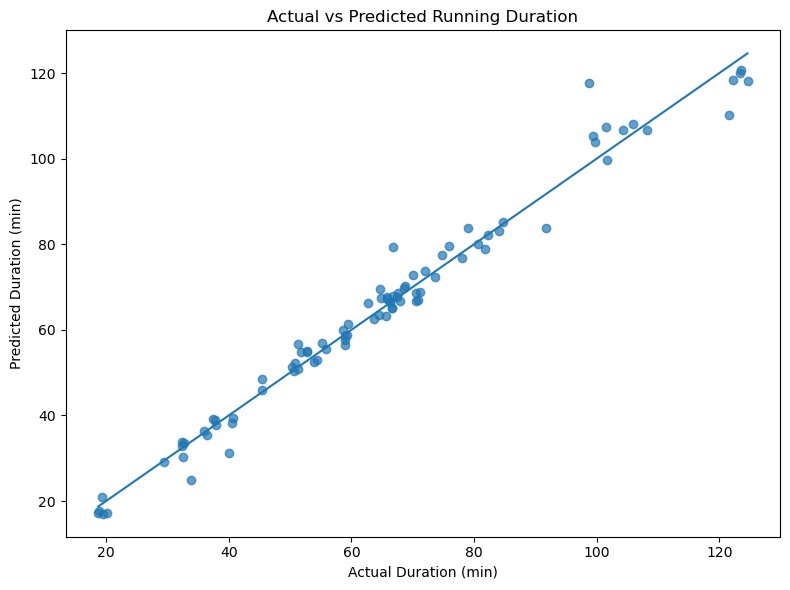

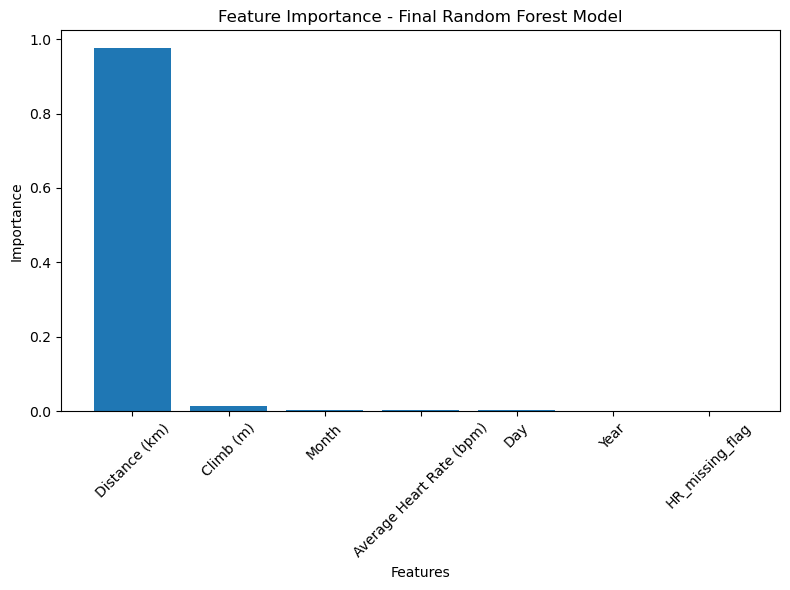

In [5]:
# Final ML Model: Predict Running Duration
# Best model selected from previous results
# Model: Random Forest Regressor
# Feature set: WITHOUT Calories Burned

# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. Load ML-ready dataset
ml_df = pd.read_csv("cleaned_cardioActivities_ml.csv")

print("Dataset shape:", ml_df.shape)
print("\nColumns:")
print(ml_df.columns.tolist())

# 3. Define final features and target
X = ml_df[
    [
        "Distance (km)",
        "Climb (m)",
        "Average Heart Rate (bpm)",
        "Year",
        "Month",
        "Day",
        "HR_missing_flag"
    ]
]

y = ml_df["Duration_min"]

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTraining set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

# 5. Train final Random Forest model
final_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

final_model.fit(X_train, y_train)

# 6. Make predictions
y_pred = final_model.predict(X_test)

# 7. Evaluate model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n===== Final Random Forest Model Results =====")
print("MAE  :", round(mae, 3))
print("RMSE :", round(rmse, 3))
print("R²   :", round(r2, 3))

# 8. Feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n===== Feature Importance =====")
print(feature_importance)

# 9. Actual vs Predicted comparison table
comparison_df = pd.DataFrame({
    "Actual_Duration_min": y_test.values,
    "Predicted_Duration_min": y_pred,
    "Residual": y_test.values - y_pred
}).reset_index(drop=True)

print("\n===== Sample Predictions =====")
print(comparison_df.head(10))

# 10. Saving outputs
feature_importance.to_csv("final_feature_importance.csv", index=False)
comparison_df.to_csv("final_actual_vs_predicted.csv", index=False)

metrics_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [mae, rmse, r2]
})
metrics_df.to_csv("final_model_metrics.csv", index=False)

print("\nFiles saved:")
print("- final_feature_importance.csv")
print("- final_actual_vs_predicted.csv")
print("- final_model_metrics.csv")

# 11. Plotting Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.xlabel("Actual Duration (min)")
plt.ylabel("Predicted Duration (min)")
plt.title("Actual vs Predicted Running Duration")
plt.tight_layout()
plt.show()

# 12. Plot: Feature Importance
plt.figure(figsize=(8, 6))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance - Final Random Forest Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
S